# Simulation Data: from a Gridded Field File to Field Line Geometry

Mageometry reads magnetic fields from simulation output (`mageometry.io`) and analyzes them with exactly the same geometry and tracing functions as model fields. This notebook walks the whole pipeline on a **synthetic but realistic dataset**: a T96 + dipole field sampled on a uniform grid and written in the XDMF + HDF5 convention used by many MHD codes. Because the reference field is known exactly, every step can be checked quantitatively — which is also how the library's own tests validate the pipeline.

Requires the optional `h5py` dependency (`pip install h5py`).

## Contents

1. [Write a compatible data file](#write)
2. [Load it: `load_xdmf` and `GriddedField`](#load)
3. [Interpolation accuracy: linear vs cubic](#interp)
4. [Curvature through the file](#curvature)
5. [Tracing through the data](#trace)
6. [The Frenet frame through the file](#frame)
7. [Directional derivatives through the file](#derivatives)
8. [Bringing your own data](#own)

In [1]:
import os
import tempfile

import numpy as np
import h5py
import matplotlib.pyplot as plt

from mageometry import (
    geopack, geopack_field, load_xdmf, GriddedField,
    trace_field_lines, field_line_curvature, field_line_frenet_frame,
    field_line_frame_quality, field_line_directional_derivatives,
    verify_unit_vectors, verify_antisymmetry_relations, viz,
)

%matplotlib inline

<a id="write"></a>
## 1. Write a compatible data file

The accepted format is documented in [`docs/simulation_data_formats.md`](../../docs/simulation_data_formats.md). The essentials of the XDMF convention:

- `3DCORECTMesh` topology with `NumberOfElements="NZ NY NX"` — **slowest axis first**;
- `ORIGIN_DXDYDZ` geometry, again listed as (z, y, x);
- HDF5 datasets stored C-order with shape `(NZ, NY, NX)`.

`load_xdmf` transposes everything to Mageometry's `(NX, NY, NZ)` convention. The writer below is the recipe from the docs; the reference field is T96 + dipole sampled on a nightside block at Δ = 0.25 Re.

In [2]:
def write_xdmf_h5(dirpath, basename, x, y, z, bx, by, bz):
    # Write (nx, ny, nz) arrays as an XDMF + HDF5 pair in the (z, y, x) on-disk convention.
    nx, ny, nz = bx.shape
    origin = (x[0], y[0], z[0])
    spacing = (x[1] - x[0], y[1] - y[0], z[1] - z[0])
    h5_path = os.path.join(dirpath, basename + ".h5")
    xmf_path = os.path.join(dirpath, basename + ".xmf")
    with h5py.File(h5_path, "w") as f:
        for name, arr in (("BX", bx), ("BY", by), ("BZ", bz)):
            f.create_dataset(name, data=arr.transpose(2, 1, 0).astype(">f4"))   # big-endian float32, (nz, ny, nx)
    with open(xmf_path, "w") as f:
        f.write(f'''<?xml version="1.0" ?>
<Xdmf Version="2.0"><Domain>
<Grid Name="Structured Grid" GridType="Uniform">
<Topology TopologyType="3DCORECTMesh" NumberOfElements="{nz} {ny} {nx}"/>
<Geometry GeometryType="ORIGIN_DXDYDZ">
<DataItem Name="Origin" Dimensions="3" NumberType="Float" Format="XML">{origin[2]} {origin[1]} {origin[0]}</DataItem>
<DataItem Name="Spacing" Dimensions="3" NumberType="Float" Format="XML">{spacing[2]} {spacing[1]} {spacing[0]}</DataItem>
</Geometry>''')
        for name in ("BX", "BY", "BZ"):
            f.write(f'''
<Attribute Name="{name}" AttributeType="Scalar" Center="Node">
<DataItem Dimensions="{nz} {ny} {nx}" NumberType="Float" Precision="4" Format="HDF">{basename}.h5:/{name}</DataItem>
</Attribute>''')
        f.write("\n</Grid></Domain></Xdmf>\n")
    return xmf_path


# Reference field
ps = geopack.recalc(100)
parmod = [2.0, -20.0, 0.0, -5.0, 0, 0, 0, 0, 0, 0]
model = geopack_field("t96", "dip", parmod, ps)

# Grid: nightside block, 0.25 Re spacing
dx = 0.25
x_ax = np.arange(-12.0, -2.0 + dx / 2, dx)
y_ax = np.arange(-4.0, 4.0 + dx / 2, dx)
z_ax = np.arange(-4.0, 4.0 + dx / 2, dx)
X, Y, Z = np.meshgrid(x_ax, y_ax, z_ax, indexing="ij")
BX, BY, BZ = model(X.ravel(), Y.ravel(), Z.ravel())
BX, BY, BZ = (b.reshape(X.shape) for b in (BX, BY, BZ))

workdir = tempfile.mkdtemp(prefix="mageometry_nb08_")
xmf_path = write_xdmf_h5(workdir, "run000", x_ax, y_ax, z_ax, BX, BY, BZ)
print("grid shape (nx, ny, nz):", X.shape, "| written:", xmf_path)

grid shape (nx, ny, nz): (41, 33, 33) | written: /tmp/mageometry_nb08_7w6l9fvb/run000.xmf


<a id="load"></a>
## 2. Load it: `load_xdmf` and `GriddedField`

A reader's only job is to construct a `GriddedField` (axes + three components). `GriddedField.field(method=...)` then builds the interpolating callable that every geometry function accepts. Data stays float32 in memory; the three components share one stacked array.

In [3]:
grid = load_xdmf(xmf_path)
print(grid)
print("dtype:", grid.b.dtype, "| bounds:", grid.bounds)
print("metadata:", grid.metadata)

# Round trip of the stored values is exact (up to the float32 write)
print("max |BX(file) - BX(model)| =", np.max(np.abs(grid.bx - BX.astype(np.float32))))

field_lin = grid.field(method="linear")   # fast; piecewise-linear
field_cub = grid.field(method="cubic")    # smooth derivatives; slower on large grids

GriddedField(shape=(41, 33, 33), x=[-12, -2], y=[-4, 4], z=[-4, 4])
dtype: float32 | bounds: ((np.float64(-12.0), np.float64(-2.0)), (np.float64(-4.0), np.float64(4.0)), (np.float64(-4.0), np.float64(4.0)))
metadata: {'source': '/tmp/mageometry_nb08_7w6l9fvb/run000.xmf', 'components': ('BX', 'BY', 'BZ'), 'center': 'node'}
max |BX(file) - BX(model)| = 0.0


<a id="interp"></a>
## 3. Interpolation accuracy: linear vs cubic

Random points inside the grid, compared with the model the file was written from.

In [4]:
rng = np.random.default_rng(0)
n = 500
xp = rng.uniform(x_ax[0], x_ax[-1], n); yp = rng.uniform(y_ax[0], y_ax[-1], n); zp = rng.uniform(z_ax[0], z_ax[-1], n)
b_ref = np.array(model(xp, yp, zp))
for name, f in (("linear", field_lin), ("cubic", field_cub)):
    b = np.array(f(xp, yp, zp))
    rel = np.linalg.norm(b - b_ref, axis=0) / np.linalg.norm(b_ref, axis=0)
    print(f"{name:7s} relative field error: median {np.median(rel):.1e}, max {rel.max():.1e}")

linear  relative field error: median 6.9e-04, max 1.0e-02
cubic   relative field error: median 1.2e-05, max 9.0e-04


<a id="curvature"></a>
## 4. Curvature through the file

The geometry functions differentiate the *interpolated* field by finite differences with step `delta`. Under linear interpolation the derivative is piecewise constant, so `delta` should be about one grid cell (Δ = 0.25 here); cubic interpolation has continuous derivatives and tolerates a smaller `delta` (0.1 below), which also keeps more frames resolvable (the quality diagnostic cos θ scales as δ²). The maps below compare curvature on the y = 0 plane computed through the file (both methods) with the direct model.

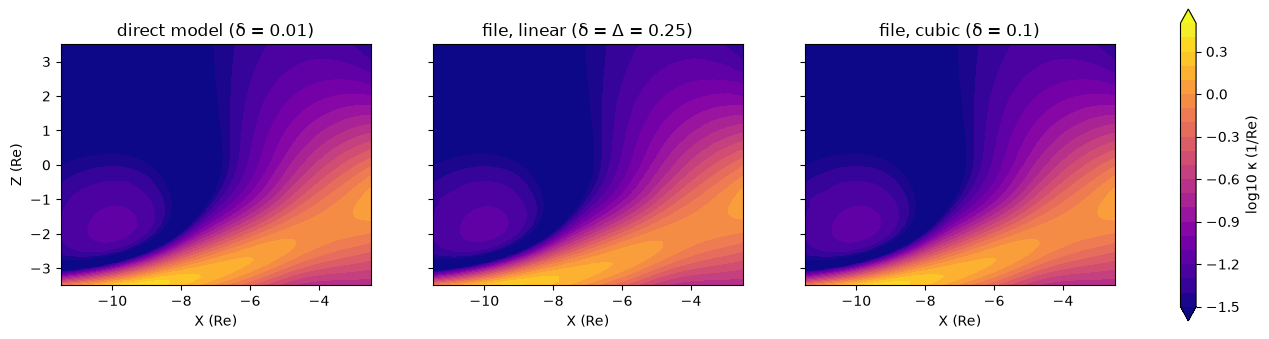

linear  curvature vs model (kappa > 0.05, 58% of points): median 5.8e-03, 95th pct 5.7e-02, max 1.5e-01
cubic   curvature vs model (kappa > 0.05, 58% of points): median 9.9e-04, 95th pct 8.3e-03, max 2.8e-02


In [5]:
xm = np.linspace(-11.5, -2.5, 73); zm = np.linspace(-3.5, 3.5, 57)
XM, ZM = np.meshgrid(xm, zm); YM = np.zeros_like(XM)
k_model = field_line_curvature(model, XM.ravel(), YM.ravel(), ZM.ravel(), delta=0.01).reshape(XM.shape)
k_lin = field_line_curvature(field_lin, XM.ravel(), YM.ravel(), ZM.ravel(), delta=dx).reshape(XM.shape)
k_cub = field_line_curvature(field_cub, XM.ravel(), YM.ravel(), ZM.ravel(), delta=0.1).reshape(XM.shape)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, k, title in zip(axes, (k_model, k_lin, k_cub), ("direct model (δ = 0.01)", "file, linear (δ = Δ = 0.25)", "file, cubic (δ = 0.1)")):
    c = ax.contourf(XM, ZM, np.log10(k), levels=np.linspace(-1.5, 0.5, 21), cmap="plasma", extend="both")
    ax.set_title(title); ax.set_xlabel("X (Re)"); ax.set_aspect("equal")
axes[0].set_ylabel("Z (Re)")
plt.colorbar(c, ax=axes, label="log10 κ (1/Re)", shrink=0.9)
plt.show()

# Relative error where the curvature is resolvable (the tail lobes have kappa -> 0,
# where any relative measure diverges).
sel = k_model > 0.05
for name, k in (("linear", k_lin), ("cubic", k_cub)):
    rel = np.abs(k / k_model - 1)[sel]
    print(f"{name:7s} curvature vs model (kappa > 0.05, {sel.mean():.0%} of points): "
          f"median {np.nanmedian(rel):.1e}, 95th pct {np.nanpercentile(rel, 95):.1e}, max {np.nanmax(rel):.1e}")

<a id="trace"></a>
## 5. Tracing through the data

`trace_field_lines` works on the interpolating callable directly. Outside the grid the interpolator returns NaN, which the tracer treats as a termination condition; passing `bounds=grid.bounds` reports those ends as boundary hits (`status` 1) with the last point placed exactly on the box face. The traced points then go back into the geometry functions — here the Frenet frame is evaluated along each line and checked for orthonormality.

FieldLineTrace(n_lines=9, max_points=70, status={'outer': 9})
status (+B end): [1 1 1 1 1 1 1 1 1]  status (-B end): [1 1 1 1 1 1 1 1 1]


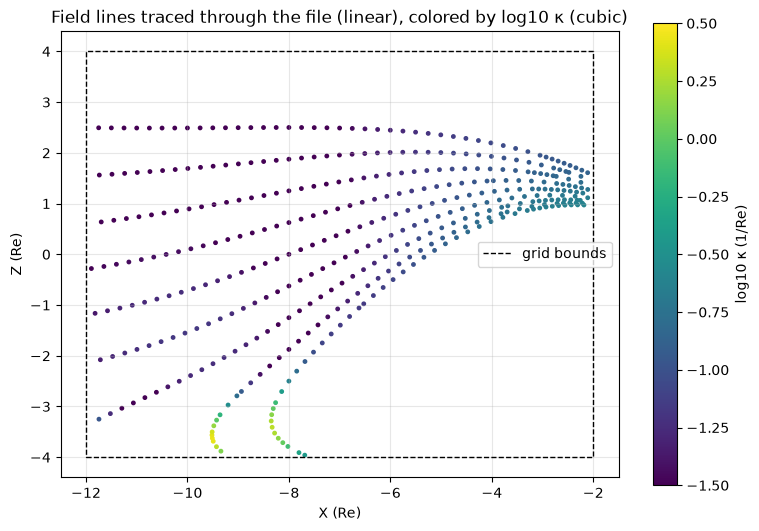

line 4: 70 points, 45 with a resolved frame (the rest lie in the weakly curved lobes); max orthonormality error 2.2e-16


In [6]:
seed_z = np.linspace(-2.5, 2.5, 9)
tr = trace_field_lines(field_lin, np.full_like(seed_z, -8.0), np.zeros_like(seed_z), seed_z,
                       direction="both", ds=dx, bounds=grid.bounds)
print(tr)
print("status (+B end):", tr.status, " status (-B end):", tr.status_backward)

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(tr.n_lines):
    x, y, z = tr.path(i)
    k = field_line_curvature(field_cub, x, y, z, delta=0.1)
    sc = ax.scatter(x, z, c=np.log10(k), s=6, cmap="viridis", vmin=-1.5, vmax=0.5)
(x0, x1), _, (z0, z1) = grid.bounds
ax.plot([x0, x1, x1, x0, x0], [z0, z0, z1, z1, z0], "k--", lw=1, label="grid bounds")
ax.set_aspect("equal"); ax.set_xlabel("X (Re)"); ax.set_ylabel("Z (Re)"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Field lines traced through the file (linear), colored by log10 κ (cubic)")
plt.colorbar(sc, ax=ax, label="log10 κ (1/Re)")
plt.show()

# Frenet frame along one line, through the file
x, y, z = tr.path(4)
frame = field_line_frenet_frame(field_cub, x, y, z, delta=0.1)
valid = np.isfinite(frame[3])   # NaN where the curvature is too small to resolve at this delta
from mageometry import verify_unit_vectors
errs = verify_unit_vectors(*(c[valid] for c in frame[:9]))
print(f"line 4: {x.size} points, {valid.sum()} with a resolved frame (the rest lie in the weakly curved "
      f"lobes); max orthonormality error {max(np.max(np.abs(e)) for e in errs.values()):.1e}")

<a id="frame"></a>
## 6. The Frenet frame through the file

The tangent needs only the field; the normal and binormal need its **derivative**, which is where interpolation quality matters. Three things to look at:

1. **Validity.** The normal is NaN where the finite difference does not resolve the curvature (`cos θ > orthogonality_tol`); `field_line_frame_quality` gives cos θ itself. Through a file, cos θ picks up interpolation noise, so more points come back NaN than for the direct model — and the fraction depends on the interpolation method and on `delta`.
2. **Accuracy.** Where both are defined, compare the file-based frame with the model frame point by point: `T_file · T_model`, `n_file · n_model`, `b_file · b_model` should all be ≈ 1.
3. **Orthonormality** is exact by construction (the normal is the projection of dT/ds perpendicular to T), regardless of data quality — so it is *not* a test of the data; the dot products above are.

First the quality diagnostic on the y = 0 plane, linear vs cubic vs the model:

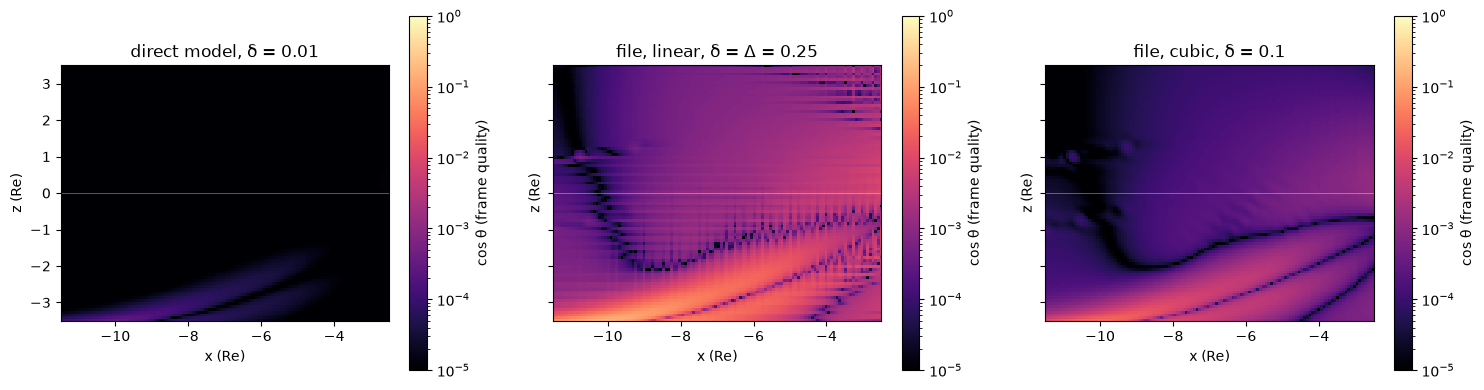

In [7]:
extent = (-11.5, -2.5, -3.5, 3.5)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6), sharey=True)
for ax, (f, dl, title) in zip(axes, [(model, 0.01, "direct model, δ = 0.01"),
                                     (field_lin, dx, f"file, linear, δ = Δ = {dx}"),
                                     (field_cub, 0.1, "file, cubic, δ = 0.1")]):
    viz.plot_geometry_map(f, "frame_quality", plane="xz", extent=extent, n=(120, 90), delta=dl,
                          ax=ax, unit="Re", vmin=1e-5, vmax=1.0)
    ax.axhline(0, color="w", lw=0.5, alpha=0.5)
    ax.set_title(title)
plt.show()

Dark = well resolved; bright = the finite difference is dominated by noise or by curvature changing faster than δ. The default tolerance (0.1) blanks the brightest pixels. With linear interpolation and δ = one cell, the tail lobes (weak, nearly straight field) are marginal almost everywhere; cubic interpolation recovers most of them.

Now the point-by-point comparison along one traced line:

line 4: 70 points
  model         frame defined at  70/70 points | min T·T 1.0000, min n·n 1.0000, min b·b 1.0000 | max orthonormality error 3e-16
  file, linear  frame defined at  43/70 points | min T·T 1.0000, min n·n 1.0000, min b·b 1.0000 | max orthonormality error 3e-16
  file, cubic   frame defined at  45/70 points | min T·T 1.0000, min n·n 1.0000, min b·b 1.0000 | max orthonormality error 2e-16


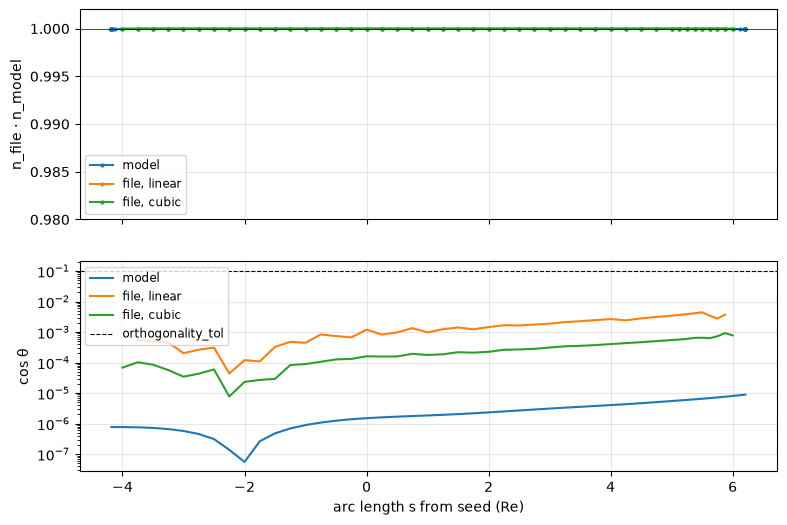

In [8]:
x, y, z = tr.path(4)
s = tr.arc_length(4)
frames = {
    "model":        field_line_frenet_frame(model, x, y, z, delta=0.01),
    "file, linear": field_line_frenet_frame(field_lin, x, y, z, delta=dx),
    "file, cubic":  field_line_frenet_frame(field_cub, x, y, z, delta=0.1),
}
ref = frames["model"]
print(f"line 4: {x.size} points")
for name, fr in frames.items():
    valid = np.isfinite(fr[3])
    both = valid & np.isfinite(ref[3])
    dots = {lab: np.sum([fr[i + k] * ref[i + k] for k in range(3)], axis=0)
            for lab, i in (("T", 0), ("n", 3), ("b", 6))}
    err = verify_unit_vectors(*(c[valid] for c in fr[:9]))
    print(f"  {name:13s} frame defined at {valid.sum():3d}/{x.size} points | "
          f"min T·T {np.nanmin(dots['T']):.4f}, min n·n {np.nanmin(dots['n'][both]):.4f}, "
          f"min b·b {np.nanmin(dots['b'][both]):.4f} | max orthonormality error "
          f"{max(np.max(np.abs(e)) for e in err.values()):.0e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for name, fr in frames.items():
    axes[0].plot(s, np.sum([fr[3 + k] * ref[3 + k] for k in range(3)], axis=0), ".-", ms=4, label=name)
    axes[1].plot(s, field_line_frame_quality(
        {"model": model, "file, linear": field_lin, "file, cubic": field_cub}[name], x, y, z,
        delta={"model": 0.01, "file, linear": dx, "file, cubic": 0.1}[name]), label=name)
axes[0].set_ylabel("n_file · n_model"); axes[0].set_ylim(0.98, 1.002); axes[0].axhline(1, color="k", lw=0.5)
axes[1].set_ylabel("cos θ"); axes[1].set_yscale("log"); axes[1].axhline(0.1, color="k", ls="--", lw=0.8, label="orthogonality_tol")
axes[1].set_xlabel("arc length s from seed (Re)")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize="small")
plt.show()

Wherever the file-based frame is defined it agrees with the model to better than 1 % (n·n > 0.99); the file-based curves simply stop where the frame becomes undefined — the weak-field lobe ends of the line, which the cubic interpolant resolves a little further than the linear one. Drawing the frames makes the same point: the file-based (cubic) frame in colour over the model frame in grey. (This line lies in the meridian, so the binormal points along y and has no in-plane projection.)

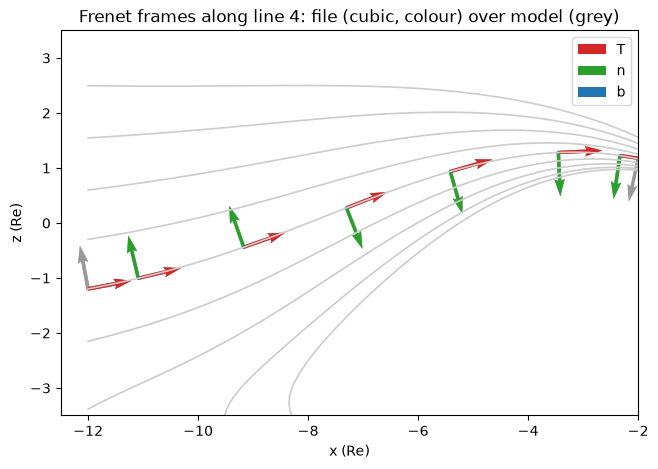

In [9]:
pick = np.arange(0, x.size, 8)
fig, ax = plt.subplots(figsize=(11, 5))
viz.plot_field_lines(tr, plane="xz", ax=ax, color="0.8", unit="Re")
viz.plot_frenet_frame(model, x[pick], y[pick], z[pick], delta=0.01, ax=ax, length=0.8,
                      color="0.6", legend=False)
viz.plot_frenet_frame(field_cub, x[pick], y[pick], z[pick], delta=0.1, ax=ax, length=0.8)
ax.set_xlim(-12.5, -2); ax.set_ylim(-3.5, 3.5)
ax.set_title("Frenet frames along line 4: file (cubic, colour) over model (grey)")
plt.show()

<a id="derivatives"></a>
## 7. Directional derivatives through the file

The nine directional derivatives differentiate the *frame* along **T**, **n**, and **b**: each is a second derivative of the field, so it is the most demanding quantity to extract from gridded data. `field_line_directional_derivatives` works unchanged on the interpolating callable; the questions are which components come out reliably and at what `delta`.

The three fields are evaluated on the same grid in the plane y = 1.5 Re (off the meridian, so that none of the nine components vanishes by symmetry): direct model (δ = 0.01), file with linear interpolation (δ = Δ), and file with cubic interpolation (δ = 0.1). The error measure is the median |file − model| over the plane, normalised by the model's typical magnitude (90th percentile of |model|) — a relative error that stays meaningful where a component passes through zero.

In [10]:
xm2 = np.linspace(-11.5, -2.5, 64); zm2 = np.linspace(-3.5, 3.5, 50)
XM2, ZM2 = np.meshgrid(xm2, zm2); YM2 = np.full_like(XM2, 1.5)
pts = (XM2.ravel(), YM2.ravel(), ZM2.ravel())
derivs = {
    "model":        field_line_directional_derivatives(model, *pts, delta=0.01),
    "file, linear": field_line_directional_derivatives(field_lin, *pts, delta=dx),
    "file, cubic":  field_line_directional_derivatives(field_cub, *pts, delta=0.1),
}
keys = ["dT_dT_n", "dn_dT_b", "dT_dn_n", "dT_dn_b", "dn_dn_b", "dn_db_b", "dn_db_T", "db_db_T"]
ref = derivs["model"]
for name, d in derivs.items():
    print(f"{name:13s} derivatives defined on {np.mean(np.isfinite(d['dT_dT_n'])):.0%} of the plane")
print()
print(f"{'key':9s} {'label':12s} {'scale (1/Re)':>13s} {'linear':>9s} {'cubic':>9s}   (median |file - model| / scale)")
for key in keys:
    v_ref = ref[key]
    scale = np.nanpercentile(np.abs(v_ref), 90)
    errs = []
    for name in ("file, linear", "file, cubic"):
        v = derivs[name][key]
        both = np.isfinite(v) & np.isfinite(v_ref)
        errs.append(np.median(np.abs(v[both] - v_ref[both])) / scale)
    print(f"{key:9s} {viz.QUANTITIES[key].label:12s} {scale:13.3f} {errs[0]:9.1%} {errs[1]:9.1%}")

# Antisymmetry: the T- and n-direction relations hold to round-off by construction
# (the frame is orthonormal), so only the b-direction relations carry information.
print("\nb-direction antisymmetry residuals, median |(∂n/∂b)·b + (∂b/∂b)·n| and |(∂b/∂b)·T + (∂T/∂b)·b|:")
for name, d in derivs.items():
    a = verify_antisymmetry_relations(d)
    print(f"  {name:13s} {np.nanmedian(np.abs(a['dn_db_b_check'])):.1e}   {np.nanmedian(np.abs(a['db_db_T_check'])):.1e}")

model         derivatives defined on 100% of the plane
file, linear  derivatives defined on 79% of the plane
file, cubic   derivatives defined on 95% of the plane

key       label         scale (1/Re)    linear     cubic   (median |file - model| / scale)
dT_dT_n   (∂T/∂T)·n            0.812      0.0%      0.0%
dn_dT_b   (∂n/∂T)·b            0.572      5.5%      0.3%
dT_dn_n   (∂T/∂n)·n            0.501      0.2%      0.0%
dT_dn_b   (∂T/∂n)·b            0.035      1.5%      0.2%
dn_dn_b   (∂n/∂n)·b            0.543      2.9%      0.6%
dn_db_b   (∂n/∂b)·b            0.624      1.5%      0.2%
dn_db_T   (∂n/∂b)·T            0.044      2.5%      0.2%
db_db_T   (∂b/∂b)·T            0.267      0.1%      0.0%

b-direction antisymmetry residuals, median |(∂n/∂b)·b + (∂b/∂b)·n| and |(∂b/∂b)·T + (∂T/∂b)·b|:
  model         1.3e-07   8.0e-08
  file, linear  8.1e-05   4.4e-05
  file, cubic   1.1e-05   7.5e-06


Reading the table: with cubic interpolation every component is recovered to well under 1 % of its typical magnitude on this 0.25 Re grid. The components that differentiate the field *direction* — κ = (∂T/∂T)·n, (∂T/∂n)·n, (∂b/∂b)·T — are essentially exact, while those that differentiate **n** or **b** across neighbouring field lines (torsion, (∂n/∂n)·b, (∂n/∂b)·b, (∂n/∂b)·T) are a few times noisier: they are second derivatives of the data. Linear interpolation is 5–20 times worse on those rows and leaves a fifth of the plane undefined; use cubic interpolation for anything beyond curvature.

The antisymmetry relations (∂v/∂u)·w = −(∂w/∂u)·v hold to round-off for the T- and n-direction pairs by construction (the frame is orthonormal), so only the two b-direction residuals printed below measure finite-difference inconsistency; compare their size with the derivative scale in the table.

Maps of four of them, file (cubic) against the model:

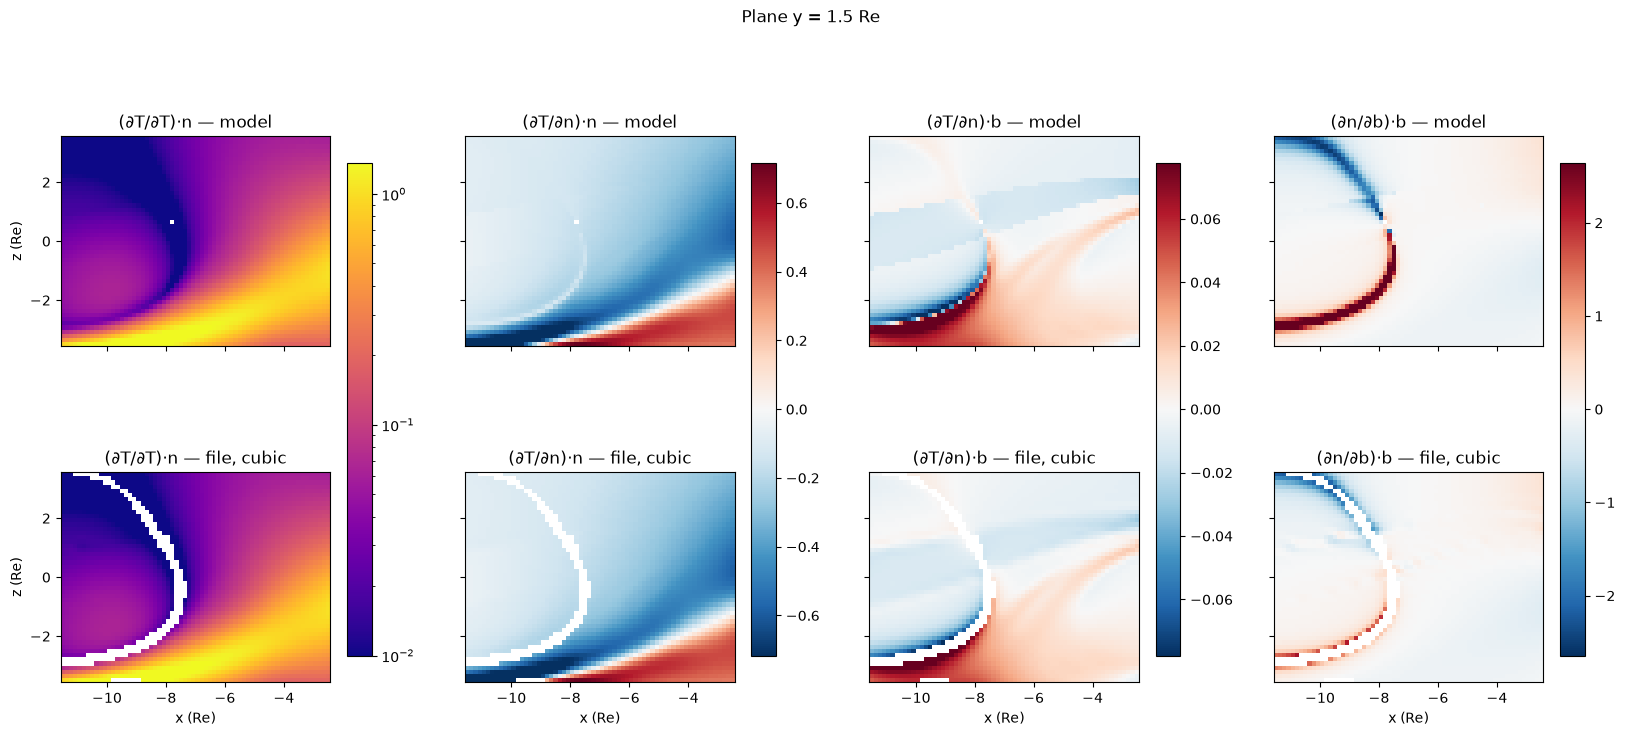

In [11]:
show = ["dT_dT_n", "dT_dn_n", "dT_dn_b", "dn_db_b"]
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
for j, key in enumerate(show):
    for i, (name, dl, f) in enumerate([("model", 0.01, model), ("file, cubic", 0.1, field_cub)]):
        q = viz.QUANTITIES[key]
        vals = derivs[name][key].reshape(XM2.shape)
        lim = np.nanpercentile(np.abs(ref[key]), 98)
        norm = plt.matplotlib.colors.Normalize(-lim, lim) if q.symmetric else plt.matplotlib.colors.LogNorm(1e-2, lim)
        m = axes[i, j].pcolormesh(XM2, ZM2, vals, norm=norm, cmap=q.cmap, shading="nearest")
        axes[i, j].set_aspect("equal")
        axes[i, j].set_title(f"{q.label} — {name}")
    plt.colorbar(m, ax=axes[:, j], shrink=0.8)
for ax in axes[1]: ax.set_xlabel("x (Re)")
for ax in axes[:, 0]: ax.set_ylabel("z (Re)")
fig.suptitle("Plane y = 1.5 Re", y=0.995)
plt.show()

Blank pixels in the file-based row are NaN: either the frame itself was unresolved (cos θ) or the normal flipped across the finite-difference stencil (`normal_flip_tol`). They cluster where the model row shows the derivative changing sign — inflection lines of the field — plus the weak-field lobes.

Finally the same quantities along a traced field line, file vs model — the form most analyses end up using. The line is seeded off the meridian (y = 1.5 Re) so that all components are non-trivial:

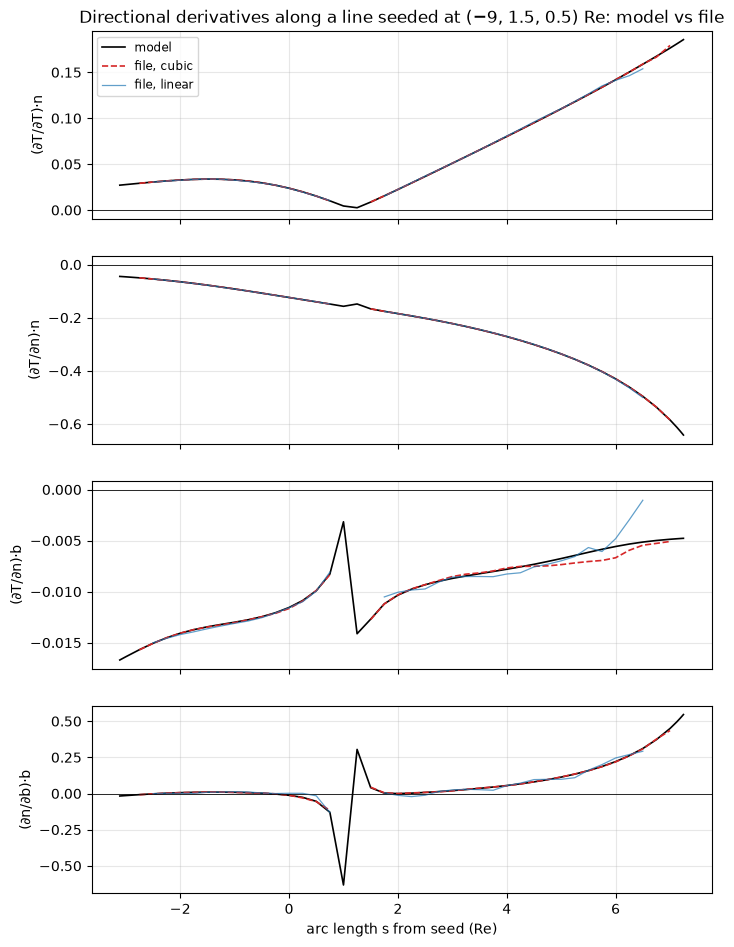

In [12]:
tr_off = trace_field_lines(field_cub, -9.0, 1.5, 0.5, direction="both", ds=dx, bounds=grid.bounds)
keys4 = ("dT_dT_n", "dT_dn_n", "dT_dn_b", "dn_db_b")
axes = viz.plot_line_profiles(tr_off, model, keys4, delta=0.01, labels=["model"], unit="Re", color="k", lw=1.2)
viz.plot_line_profiles(tr_off, field_cub, keys4, delta=0.1, axes=axes, labels=["file, cubic"],
                       color="tab:red", lw=1.2, ls="--")
viz.plot_line_profiles(tr_off, field_lin, keys4, delta=dx, axes=axes, labels=["file, linear"],
                       color="tab:blue", lw=0.9, alpha=0.7)
axes[0].set_title("Directional derivatives along a line seeded at (−9, 1.5, 0.5) Re: model vs file")
plt.show()

Where a component has a sharp feature — the spike of (∂n/∂b)·b near s ≈ 1 is the field line's normal rotating rapidly through the current sheet — the file-based estimate is smoothed or dropped (NaN) at the grid's resolution, while the smooth parts of every profile are reproduced. That is the general pattern: gridded data reproduces the Frenet frame and its derivatives faithfully at scales of a few cells and cannot resolve features below one cell.

**Practical summary for gridded data**

- Curvature, torsion, and the Frenet frame are robust with cubic interpolation and δ of a fraction of a cell; with linear interpolation use δ ≈ one cell and expect the frame to be undefined in weakly curved regions.
- The derivatives of **n** and **b** across field lines are second derivatives of the data: expect NaN gaps and noise at the grid's resolution limit, use cubic interpolation, and read the antisymmetry residuals as your error bar.
- NaN is information: it marks where the grid cannot support the quantity. Mask with `np.isfinite`, do not fill.

<a id="own"></a>
## 8. Bringing your own data

- **XDMF + HDF5** in the convention above: `load_xdmf("run.xmf")` (pass `h5_file=` if the heavy-data file was renamed).
- **Plain HDF5** datasets: `load_hdf5("run.h5", datasets=("BX","BY","BZ"), origin=(x0,y0,z0), spacing=(dx,dy,dz))`.
- **Anything else** (VTK, NetCDF, in-memory arrays, non-uniform rectilinear grids): build the arrays yourself and construct `GriddedField(x, y, z, bx, by, bz)` directly. Units are your own throughout — rescale the axes or field arrays first if you need Re and nT.

Large runs rarely need to be loaded whole: every reader accepts `region=((xmin, xmax), (ymin, ymax), (zmin, zmax))` and `stride` to read only a sub-box or every n-th node (as an HDF5 hyperslab, so the full array never enters memory), and `GriddedField.subvolume` does the same for data already in memory. Time series (XDMF temporal collections or ParaView `.xmf.series` indexes) open lazily with `load_xdmf_series(path)` — `series.times`, `series[i]`, `series.at(t)`.

For example, a subvolume for detailed (cubic) analysis:

In [13]:
sub = grid.subvolume(region=((-10.0, -6.0), (-2.0, 2.0), (-2.0, 2.0)))
print(sub)
# the same box straight from the file, reading only those nodes:
print(load_xdmf(xmf_path, region=((-10.0, -6.0), (-2.0, 2.0), (-2.0, 2.0))))
k_sub = field_line_curvature(sub.field("cubic"), -8.0, 0.0, 0.0, delta=dx)
print(f"curvature at (-8, 0, 0): subvolume cubic {k_sub:.4f} | model {field_line_curvature(model, -8.0, 0.0, 0.0):.4f} 1/Re")

# clean up the temporary files
import shutil
shutil.rmtree(workdir, ignore_errors=True)

GriddedField(shape=(17, 17, 17), x=[-10, -6], y=[-2, 2], z=[-2, 2])
GriddedField(shape=(17, 17, 17), x=[-10, -6], y=[-2, 2], z=[-2, 2])
curvature at (-8, 0, 0): subvolume cubic 0.0105 | model 0.0105 1/Re
